# Stream Station Typology

Principal component analysis and clustering of Massachusetts stream monitoring
stations from total-phosphorus, soil, and land-cover attributes.

**Training set:** 53 sites. The 11 held-out sites are classified in
`sst-validation.ipynb`.

Pipeline: **data input → correlation → PCA → choose k → cluster (Ward / k-means)
→ profiles → save model.** Clustering uses the first **5** principal components;
set `CLUSTER_METHOD` to `"ward"` or `"kmeans"`.

In [1]:
# --- Setup & configuration ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score)

# Paths resolve whether the notebook runs from bin/ or the project root
ROOT = Path.cwd()
ROOT = ROOT.parent if ROOT.name == "bin" else ROOT
DATA = ROOT / "data" / "tidy" / "MA_Combined_streams_TP_soil_LULC_within_50m(in).csv"
OUT = ROOT / "results"        # data artifacts: CSV + joblib
FIG = ROOT / "figures"        # all plots
for _d in (OUT, FIG):
    _d.mkdir(exist_ok=True)

FEATURES = ["GMeanTP", "sen_slope", "TFACTOR", "AWS100", "AWS25", "DEP2WATTBL",
            "SLOPE_1", "CM2RESLYR", "KFACTWS", "PHWATER", "CLAY", "KSAT", "OM",
            "SAND", "Land_Cover_Encoded"]
ID_COLS = ["MonitoringLocationName", "Latitude", "Longitude"]

# Component names capture stream TP dynamics (concentration + Sen slope) alongside
# the surrounding soil properties and land-use classification (see PCA cell).
PC_NAMES = {
    "PC1": "Soil Permeability",
    "PC2": "Soil Quality",
    "PC3": "Soil Resilience",
    "PC4": "Internal Loading Potential",
    "PC5": "Non-point Source Potential",
}

# Type names for the size-ordered clusters (0 = largest; see interpretation cell)
CLUSTER_NAMES = {
    0: "Legacy P Sourced Riparian",
    1: "Stable Soil Riparian",
    2: "Eutrophication Potential Riparian",
    3: "Runoff Sourced Riparian",
}

VARIABLE_LABELS = {
    "GMeanTP": "Geometric Mean TP (µg/L)",
    "sen_slope": "TP Sen Slope (µg/L)",
    "TFACTOR": "Soil Tolerance Factor",
    "AWS100": "Available Water Storage 0-100 cm",
    "AWS25": "Available Water Storage 0-25 cm",
    "DEP2WATTBL": "Depth to Water Table (cm)",
    "SLOPE_1": "Soil Slope",
    "CM2RESLYR": "Depth to Restrictive Layer (cm)",
    "KFACTWS": "Whole Soil Erodibility Factor",
    "PHWATER": "Soil pH",
    "CLAY": "Percent Clay",
    "KSAT": "Saturated Hydraulic Conductivity (in/hr)",
    "OM": "Percent Organic Matter",
    "SAND": "Percent Sand",
    "Land_Cover_Encoded": "Land Cover",
}

# 11 sites held out for validation
TEST_SITES = [
    "Doolittle Brook", "Eastman Brook Downstream", "Eastman Brook Upstream",
    "Horse Farm Brook Downstream", "Horse Farm Brook Upstream", "Knightly Brook",
    "Lake Warner Mill River", "Lake Warner Outlet", "Roaring Brook",
    "Tan Brook Downstream", "Tan Brook Upstream",
]

N_PCS_CLUSTER = 5           # cluster on the first 5 principal components
K = 4                       # cluster count (justified by the diagnostics cell)
CLUSTER_METHOD = "ward"     # "ward" (hierarchical) or "kmeans"
RANDOM_STATE = 45
PALETTE = list(plt.get_cmap("tab10").colors)

In [2]:
# --- Figure style: larger fonts for paper-ready figures ---
plt.rcParams.update({
    "axes.labelsize": 15,
    "axes.titlesize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
})

In [3]:
# --- Data input: encode land cover, hold out validation sites ---
df = pd.read_csv(DATA)

# Encode land cover from the full dataset so the mapping matches validation
lulc_mapping = {name: i for i, name in enumerate(sorted(df["Land_Cover"].unique()))}
df["Land_Cover_Encoded"] = df["Land_Cover"].map(lulc_mapping)

train = df[~df["MonitoringLocationName"].isin(TEST_SITES)].reset_index(drop=True)
train = train.dropna(subset=FEATURES)
X = train[FEATURES]

print(f"Training sites: {len(train)}   Features: {len(FEATURES)}   "
      f"Land-cover classes: {len(lulc_mapping)}")
train[ID_COLS + FEATURES].head()

Training sites: 53   Features: 15   Land-cover classes: 11


,MonitoringLocationName,Latitude,Longitude,GMeanTP,sen_slope,TFACTOR,AWS100,AWS25,DEP2WATTBL,SLOPE_1,CM2RESLYR,KFACTWS,PHWATER,CLAY,KSAT,OM,SAND,Land_Cover_Encoded
0,Assabet River,42.30,-71.63,106.3,-0.7,3,12.01,3.44,51,5,81,0.28,5.2,7.0,10.0000,7.01,61.0,1
1,Blackstone River,42.23,-71.79,100.5,-0.2,3,4.73,1.80,0,8,0,0.10,4.6,2.0,100.0000,2.80,81.0,4
2,Cady Brook,42.12,-72.01,26.5,-0.4,2,10.61,4.21,0,9,76,0.28,4.2,9.0,10.0001,10.00,58.0,8
3,"Central Cemetery, Millbury",42.19,-71.77,67.6,0.0,4,23.40,7.25,8,1,0,0.32,6.2,9.5,9.1700,15.00,64.1,1
4,Concord River,42.64,-71.30,62.4,-0.6,4,5.27,1.82,0,5,0,0.28,5.1,5.4,100.0000,4.12,60.1,4


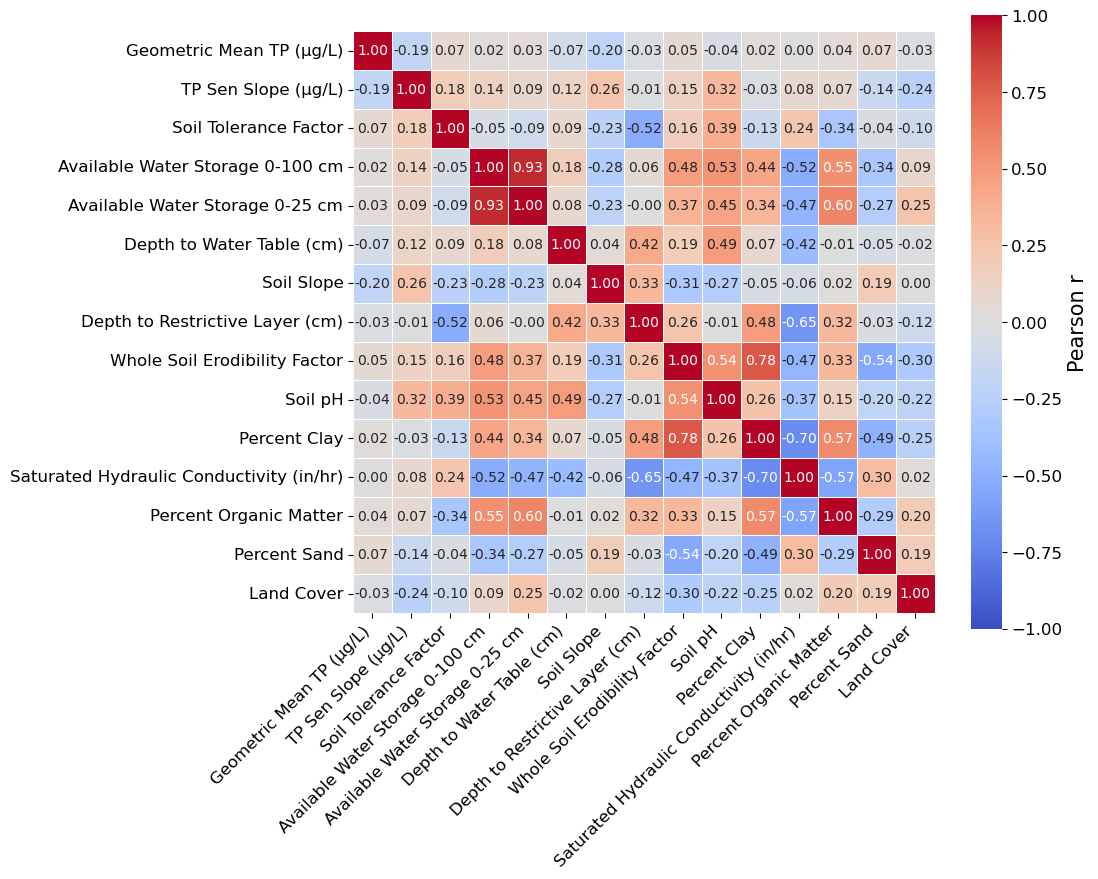

In [4]:
# --- Correlation analysis (optional; set RUN_CORRELATION = False to skip) ---
RUN_CORRELATION = True
if RUN_CORRELATION:
    corr = X.corr(method="pearson")
    labels = [VARIABLE_LABELS.get(c, c) for c in corr.columns]
    fig, ax = plt.subplots(figsize=(11, 9))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
                square=True, linewidths=.5, cbar_kws={"label": "Pearson r"},
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    fig.tight_layout()
    fig.savefig(FIG / "correlation-heatmap.png", dpi=200)
    corr.to_csv(OUT / "correlation-matrix.csv")
    plt.show()

In [5]:
# --- PCA ---
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

pca = PCA().fit(X_std)
scores = pca.transform(X_std)

# Loadings = correlation of each variable with each component
loadings = pd.DataFrame(pca.components_.T * np.sqrt(pca.explained_variance_),
                        index=FEATURES,
                        columns=[f"PC{i+1}" for i in range(pca.n_components_)])

variance = pd.DataFrame({
    "PC": loadings.columns,
    "Variance %": (pca.explained_variance_ratio_ * 100).round(2),
    "Cumulative %": (np.cumsum(pca.explained_variance_ratio_) * 100).round(2),
    "Eigenvalue": pca.explained_variance_.round(3),
})
n90 = int(np.argmax(np.cumsum(pca.explained_variance_ratio_) >= .90) + 1)
print(f"PCs needed for 90% cumulative variance: {n90}\n")
print(variance.to_string(index=False))

# Top variables driving each retained component (justifies the PC names)
print("\nDominant loadings per retained component:")
for i in range(N_PCS_CLUSTER):
    pc = f"PC{i+1}"
    top = loadings[pc].sort_values(key=abs, ascending=False).head(4)
    drivers = ", ".join(f"{VARIABLE_LABELS.get(v, v)} ({loadings.loc[v, pc]:+.2f})"
                        for v in top.index)
    print(f"  {pc} — {PC_NAMES[pc]}: {drivers}")
loadings.iloc[:, :N_PCS_CLUSTER].round(3)

PCs needed for 90% cumulative variance: 8

  PC  Variance %  Cumulative %  Eigenvalue
 PC1       30.44         30.44       4.654
 PC2       15.35         45.79       2.347
 PC3       12.44         58.23       1.902
 PC4        9.83         68.06       1.503
 PC5        8.44         76.50       1.290
 PC6        5.93         82.43       0.907
 PC7        4.38         86.81       0.670
 PC8        3.93         90.74       0.602
 PC9        2.89         93.64       0.442
PC10        2.13         95.77       0.326
PC11        1.46         97.23       0.224
PC12        1.30         98.53       0.199
PC13        0.75         99.29       0.115
PC14        0.43         99.71       0.066
PC15        0.29        100.00       0.044

Dominant loadings per retained component:
  PC1 — Soil Permeability: Saturated Hydraulic Conductivity (in/hr) (+0.82), Percent Clay (-0.81), Available Water Storage 0-100 cm (-0.81), Whole Soil Erodibility Factor (-0.78)
  PC2 — Soil Quality: Soil Tolerance Factor (+0

,PC1,PC2,PC3,PC4,PC5
GMeanTP,-0.005,0.092,0.246,-0.397,0.439
sen_slope,-0.146,0.255,-0.441,0.435,-0.531
TFACTOR,0.108,0.801,-0.196,0.050,0.124
AWS100,-0.806,0.201,0.367,0.244,-0.065
AWS25,-0.728,0.141,0.521,0.312,-0.091
DEP2WATTBL,-0.351,-0.013,-0.449,0.452,0.572
SLOPE_1,0.185,-0.575,-0.375,0.343,-0.301
CM2RESLYR,-0.437,-0.723,-0.388,-0.017,0.230
KFACTWS,-0.782,0.271,-0.220,-0.338,-0.022
PHWATER,-0.601,0.547,-0.250,0.320,0.214


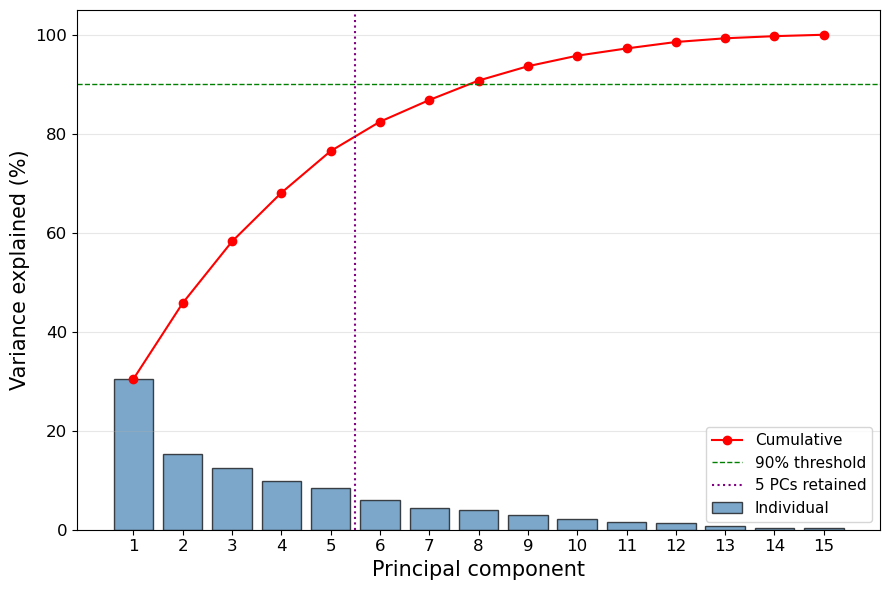

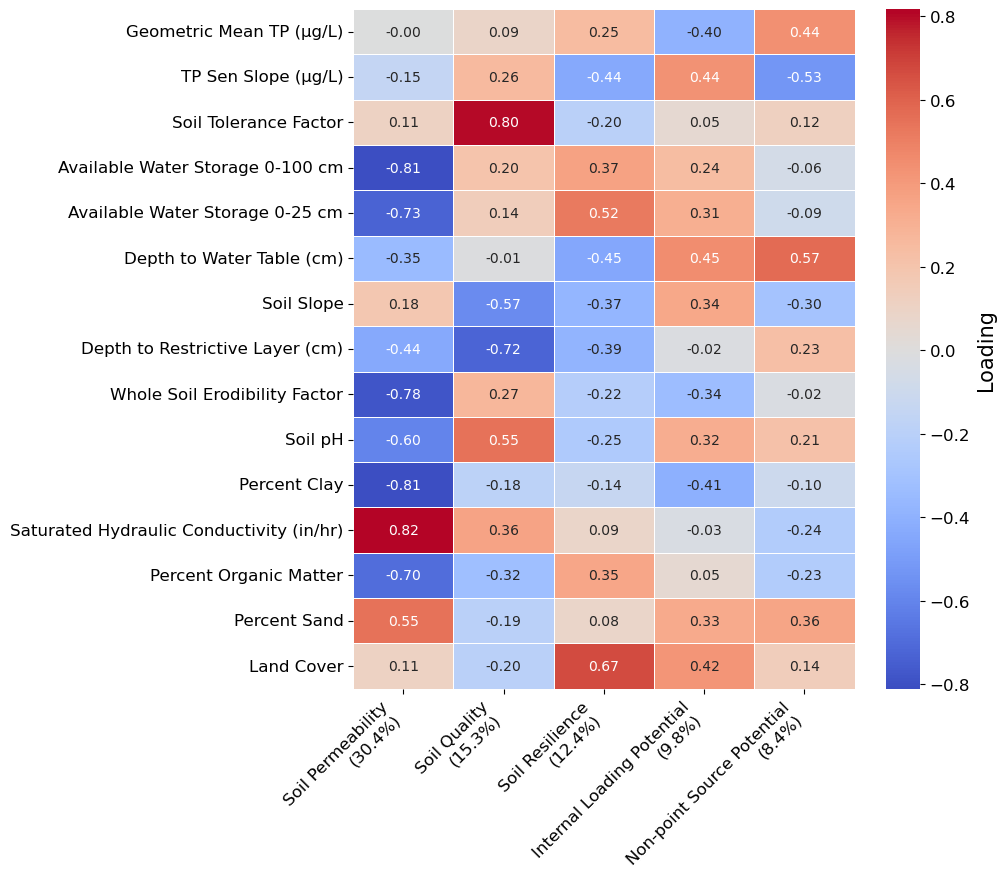

In [6]:
# --- PCA visualization: scree plot and loadings heatmap (saved separately) ---
pcs = np.arange(1, pca.n_components_ + 1)
vpct = pca.explained_variance_ratio_ * 100
cum = np.cumsum(vpct)

# Scree plot
fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(pcs, vpct, color="steelblue", edgecolor="black", alpha=.7, label="Individual")
ax.plot(pcs, cum, "ro-", label="Cumulative")
ax.axhline(90, color="green", ls="--", lw=1, label="90% threshold")
ax.axvline(N_PCS_CLUSTER + .5, color="purple", ls=":", lw=1.5,
           label=f"{N_PCS_CLUSTER} PCs retained")
ax.set(xlabel="Principal component", ylabel="Variance explained (%)")
ax.set_xticks(pcs)
ax.legend()
ax.grid(axis="y", alpha=.3)
fig.tight_layout()
fig.savefig(FIG / "scree.png", dpi=200)
plt.show()

# Loadings heatmap (component names only, no "PCx")
disp = loadings.iloc[:, :N_PCS_CLUSTER].copy()
disp.index = [VARIABLE_LABELS.get(f, f) for f in disp.index]
disp.columns = [f"{PC_NAMES.get(c, c)}\n({v:.1f}%)"
                for c, v in zip(disp.columns, vpct)]
fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(disp, cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=.5,
            cbar_kws={"label": "Loading"}, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_ylim(len(disp), 0)          # keep top/bottom rows from being clipped
fig.tight_layout()
fig.savefig(FIG / "loadings-heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

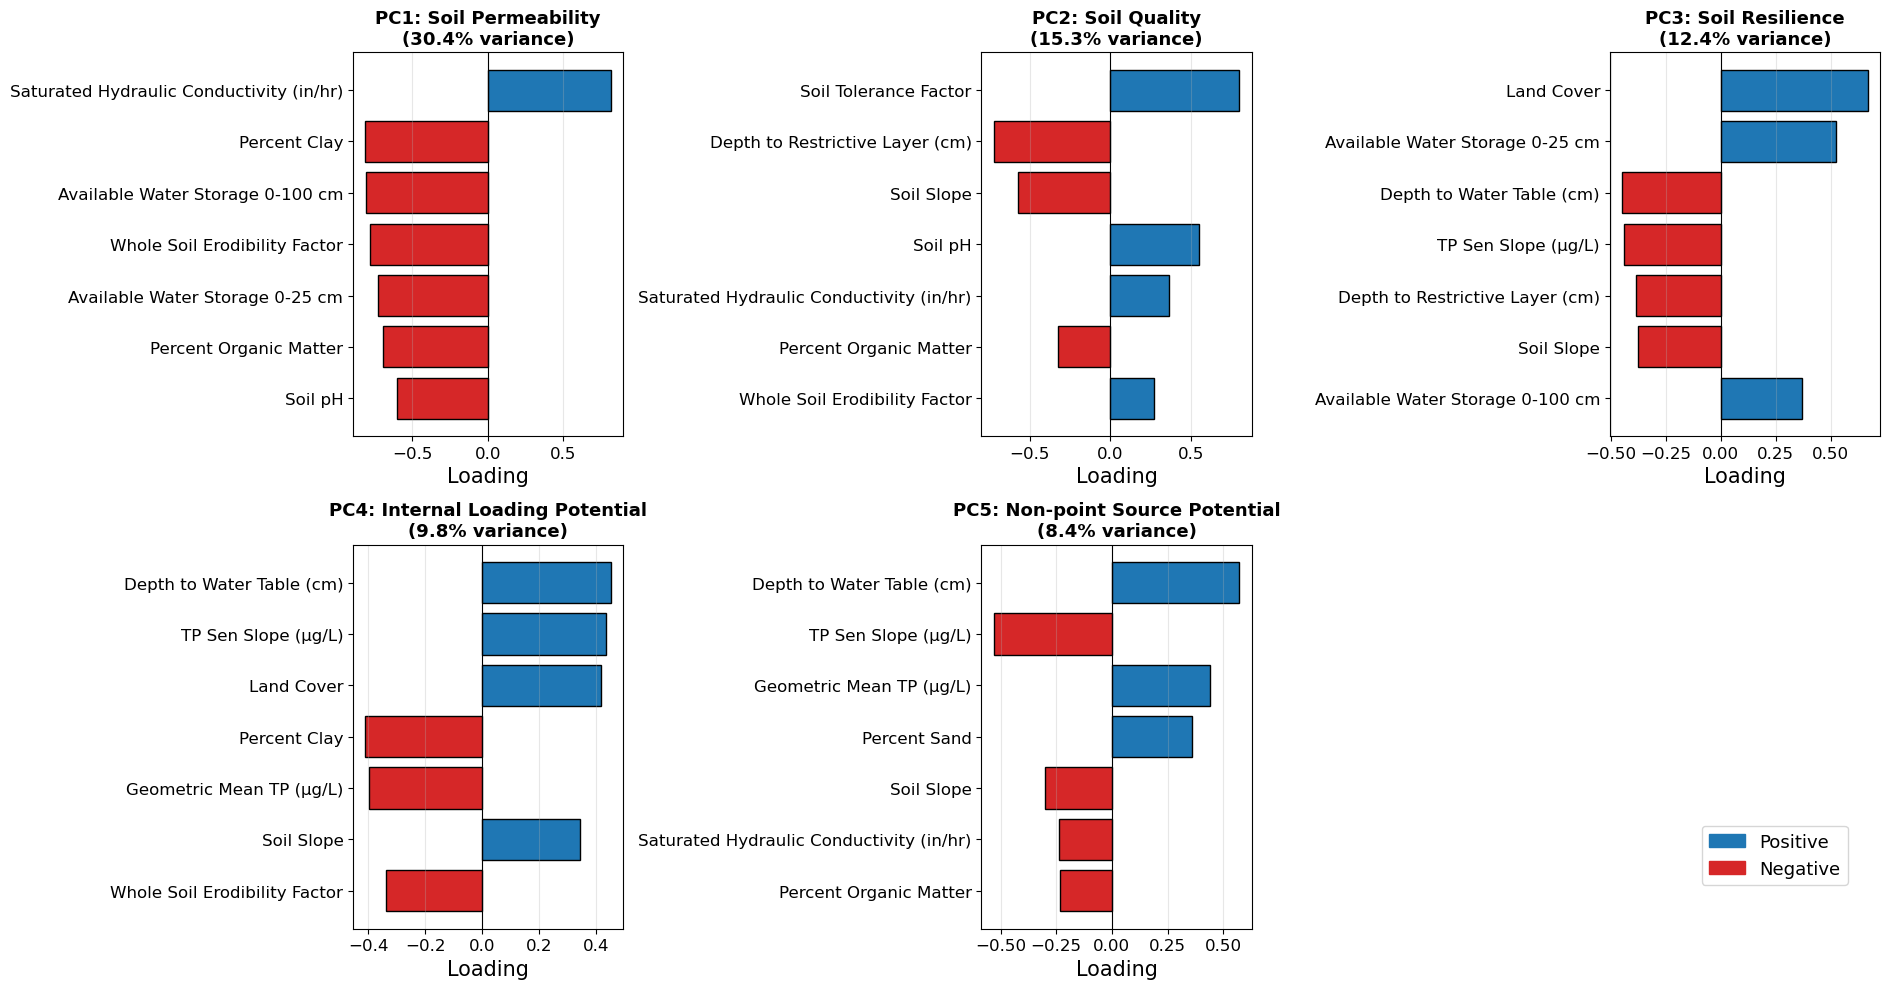

In [7]:
# --- Loadings facets: the 7 strongest |loadings| per retained PC ---
from matplotlib.patches import Patch

top_k = 7
pos_c, neg_c = "#1f77b4", "#d62728"
nrow, ncol = 2, 3
fig, axes = plt.subplots(nrow, ncol, figsize=(19, 10))
axes = axes.ravel()
for i in range(N_PCS_CLUSTER):
    ax = axes[i]
    pc = f"PC{i+1}"
    s = loadings[pc]
    top = s.reindex(s.abs().sort_values(ascending=False).index).head(top_k)
    top = top.iloc[::-1]               # largest |loading| ends up at the top of barh
    colors = [pos_c if v >= 0 else neg_c for v in top.values]
    ax.barh(range(len(top)), top.values, color=colors, edgecolor="black")
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([VARIABLE_LABELS.get(v, v) for v in top.index])
    ax.axvline(0, color="k", lw=.8)
    ax.set_title(f"{pc}: {PC_NAMES[pc]}\n"
                 f"({pca.explained_variance_ratio_[i] * 100:.1f}% variance)",
                 fontweight="bold")
    ax.set_xlabel("Loading")
    ax.grid(axis="x", alpha=.3)
for j in range(N_PCS_CLUSTER, nrow * ncol):
    fig.delaxes(axes[j])
fig.legend(handles=[Patch(color=pos_c, label="Positive"),
                    Patch(color=neg_c, label="Negative")],
           loc="lower right", bbox_to_anchor=(0.98, 0.1), fontsize=13)
fig.tight_layout()
fig.savefig(FIG / "loadings-facets.png", dpi=200, bbox_inches="tight")
plt.show()

In [8]:
# --- Clustering helpers (shared by both methods) ---
Z = scores[:, :N_PCS_CLUSTER]        # cluster on the first 5 PCs
K_RANGE = range(2, 11)

def cluster_labels(data, k, method):
    """k-means or Ward labels, relabeled so cluster 0 is the largest."""
    if method == "kmeans":
        lab = KMeans(k, random_state=RANDOM_STATE, n_init=10).fit_predict(data)
    else:
        lab = AgglomerativeClustering(k, linkage="ward").fit_predict(data)
    order = pd.Series(lab).value_counts().index.tolist()   # descending size
    remap = {old: i for i, old in enumerate(order)}
    return np.array([remap[v] for v in lab])

def centroids_of(data, labels):
    return np.vstack([data[labels == c].mean(0) for c in range(labels.max() + 1)])

def diagnostics(data, method):
    labs = {k: cluster_labels(data, k, method) for k in K_RANGE}
    tbl = pd.DataFrame({k: {"Silhouette": silhouette_score(data, l),
                            "Davies-Bouldin": davies_bouldin_score(data, l),
                            "Calinski-Harabasz": calinski_harabasz_score(data, l)}
                        for k, l in labs.items()}).T
    return tbl, labs

         Ward                                     k-means                                  agreement
   Silhouette Davies-Bouldin Calinski-Harabasz Silhouette Davies-Bouldin Calinski-Harabasz Adj. Rand
2       0.288          1.382            22.249      0.290          1.393            22.369     0.925
3       0.322          1.372            19.898      0.323          1.213            20.153     0.709
4       0.314          1.235            19.186      0.328          1.154            20.707     0.694
5       0.323          1.131            18.806      0.343          1.106            20.426     0.697
6       0.345          1.087            19.517      0.355          1.102            19.829     0.742
7       0.378          1.033            19.806      0.380          1.013            20.169     0.798
8       0.378          1.005            19.812      0.369          0.921            19.174     0.745
9       0.393          0.979            20.228      0.368          0.938            20.601 

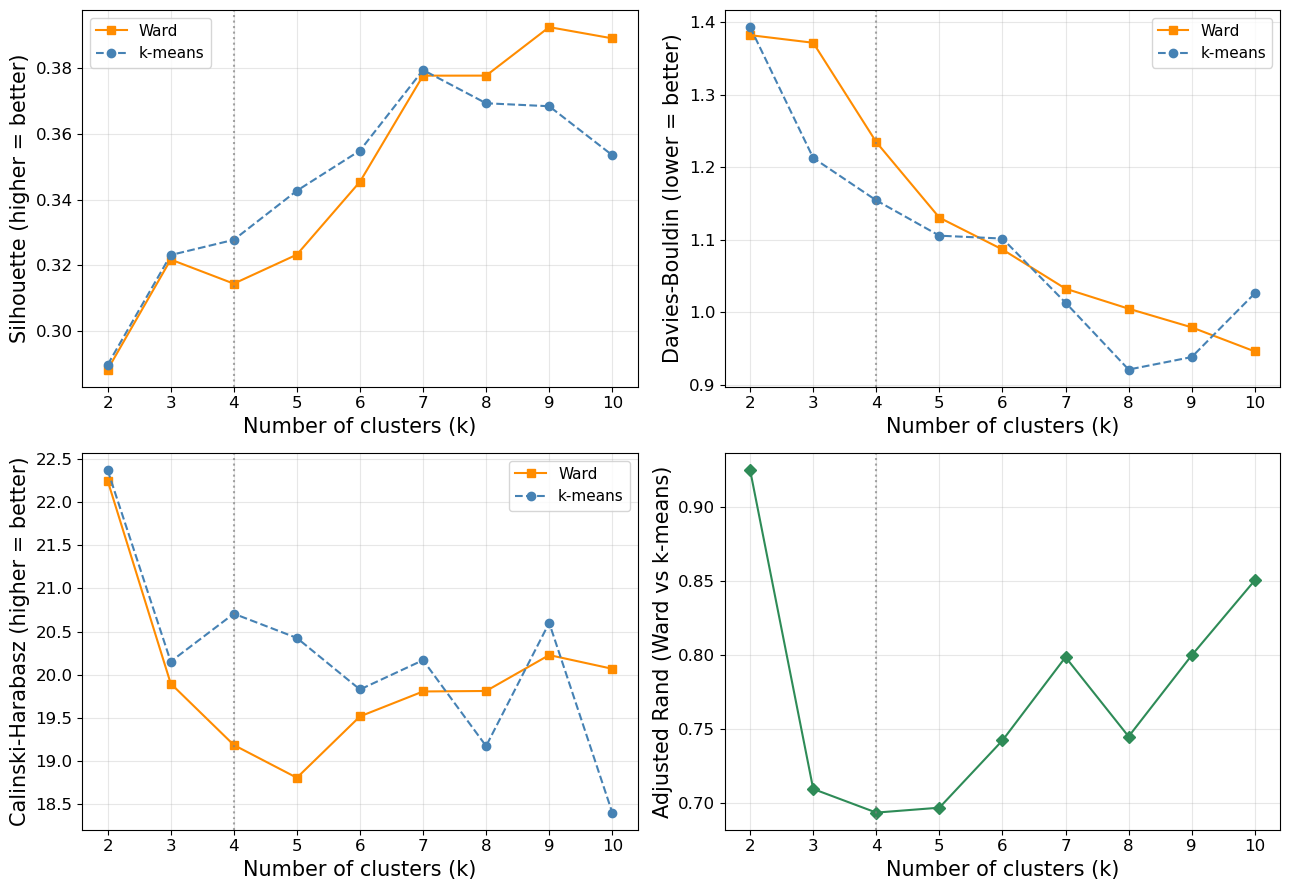

In [9]:
# --- Choosing k: Ward vs k-means across candidate cluster counts ---
diag_wd, labs_wd = diagnostics(Z, "ward")
diag_km, labs_km = diagnostics(Z, "kmeans")

# Adjusted Rand index between the two methods at each k (agreement / robustness)
ari = pd.Series({k: adjusted_rand_score(labs_wd[k], labs_km[k]) for k in K_RANGE})

compare = pd.concat({"Ward": diag_wd, "k-means": diag_km}, axis=1)
compare[("agreement", "Adj. Rand")] = ari
print(compare.round(3).to_string())
print(f"\nChosen K = {K}, method = {CLUSTER_METHOD}")

# 2 x 2 layout (paper-friendly): three internal metrics + method agreement
panels = [("Silhouette", "higher"), ("Davies-Bouldin", "lower"),
          ("Calinski-Harabasz", "higher")]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()
for ax, (name, better) in zip(axes, panels):
    ax.plot(diag_wd.index, diag_wd[name], "s-", color="darkorange", label="Ward")
    ax.plot(diag_km.index, diag_km[name], "o--", color="steelblue", label="k-means")
    ax.axvline(K, color="grey", ls=":", alpha=.7)
    ax.set(xlabel="Number of clusters (k)", ylabel=f"{name} ({better} = better)")
    ax.set_xticks(list(K_RANGE))
    ax.grid(alpha=.3)
    ax.legend()
axes[3].plot(ari.index, ari.values, "D-", color="seagreen")
axes[3].axvline(K, color="grey", ls=":", alpha=.7)
axes[3].set(xlabel="Number of clusters (k)",
            ylabel="Adjusted Rand (Ward vs k-means)")
axes[3].set_xticks(list(K_RANGE))
axes[3].grid(alpha=.3)
fig.tight_layout()
fig.savefig(FIG / "cluster-metrics.png", dpi=200)
plt.show()

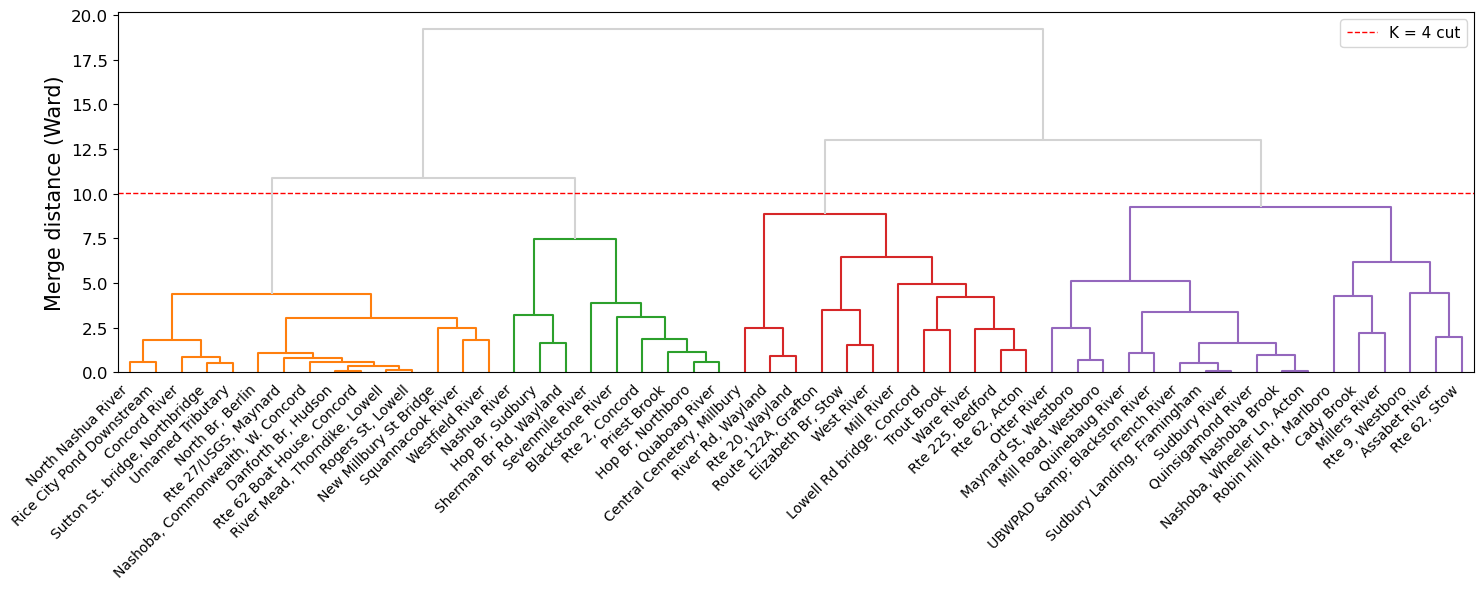

In [10]:
# --- Ward dendrogram (hierarchy behind the chosen cut) ---
link = linkage(Z, method="ward")
d = np.sort(link[:, 2])
thr = 0.5 * (d[-K] + d[-(K - 1)])     # cut that yields K clusters

# Singleton sites (size-1 Ward clusters) get a blue leaf label instead of grey
_wl = cluster_labels(Z, K, "ward")
_sizes = pd.Series(_wl).value_counts()
singleton_sites = set(train["MonitoringLocationName"].values[
    np.isin(_wl, _sizes.index[_sizes == 1])])

fig, ax = plt.subplots(figsize=(15, 6))
dendrogram(link, labels=train["MonitoringLocationName"].values,
           color_threshold=thr, above_threshold_color="lightgrey", ax=ax)
ax.axhline(thr, color="red", ls="--", lw=1, label=f"K = {K} cut")
ax.set(ylabel="Merge distance (Ward)")
ax.tick_params(axis="x", labelsize=10)
for lbl in ax.get_xticklabels():
    lbl.set_rotation(45)
    lbl.set_ha("right")
    if lbl.get_text() in singleton_sites:
        lbl.set_color(PALETTE[0])          # blue, to match the other plots
        lbl.set_fontweight("bold")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "ward-dendrogram.png", dpi=200)
plt.show()

Method: ward   K = 4   silhouette = 0.314   agreement with kmeans (ARI) = 0.694

Cluster sizes:
Cluster
0    17
1    15
2    12
3     9


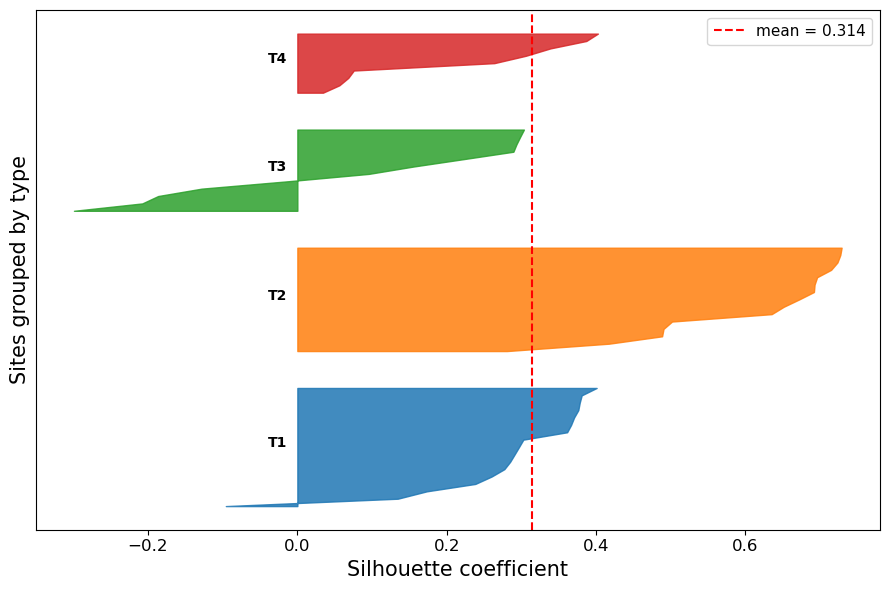

In [11]:
# --- Fit the chosen clustering and inspect the per-site silhouette plot ---
labels = cluster_labels(Z, K, CLUSTER_METHOD)
train["Cluster"] = labels
centers = centroids_of(Z, labels)

other = "kmeans" if CLUSTER_METHOD == "ward" else "ward"
agree = adjusted_rand_score(labels, cluster_labels(Z, K, other))
sil_avg = silhouette_score(Z, labels)
print(f"Method: {CLUSTER_METHOD}   K = {K}   silhouette = {sil_avg:.3f}   "
      f"agreement with {other} (ARI) = {agree:.3f}")
print("\nCluster sizes:")
print(train["Cluster"].value_counts().sort_index().to_string())

sil_vals = silhouette_samples(Z, labels)
fig, ax = plt.subplots(figsize=(9, 6))
y = 0
for c in range(K):
    vals = np.sort(sil_vals[labels == c])
    ax.fill_betweenx(np.arange(y, y + len(vals)), 0, vals, color=PALETTE[c], alpha=.85)
    ax.text(-0.04, y + len(vals) / 2, f"T{c + 1}", va="center", fontweight="bold")
    y += len(vals) + 4
ax.axvline(sil_avg, color="red", ls="--", label=f"mean = {sil_avg:.3f}")
ax.set(xlabel="Silhouette coefficient", ylabel="Sites grouped by type")
ax.set_yticks([])
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "silhouette-knife.png", dpi=200)
plt.show()

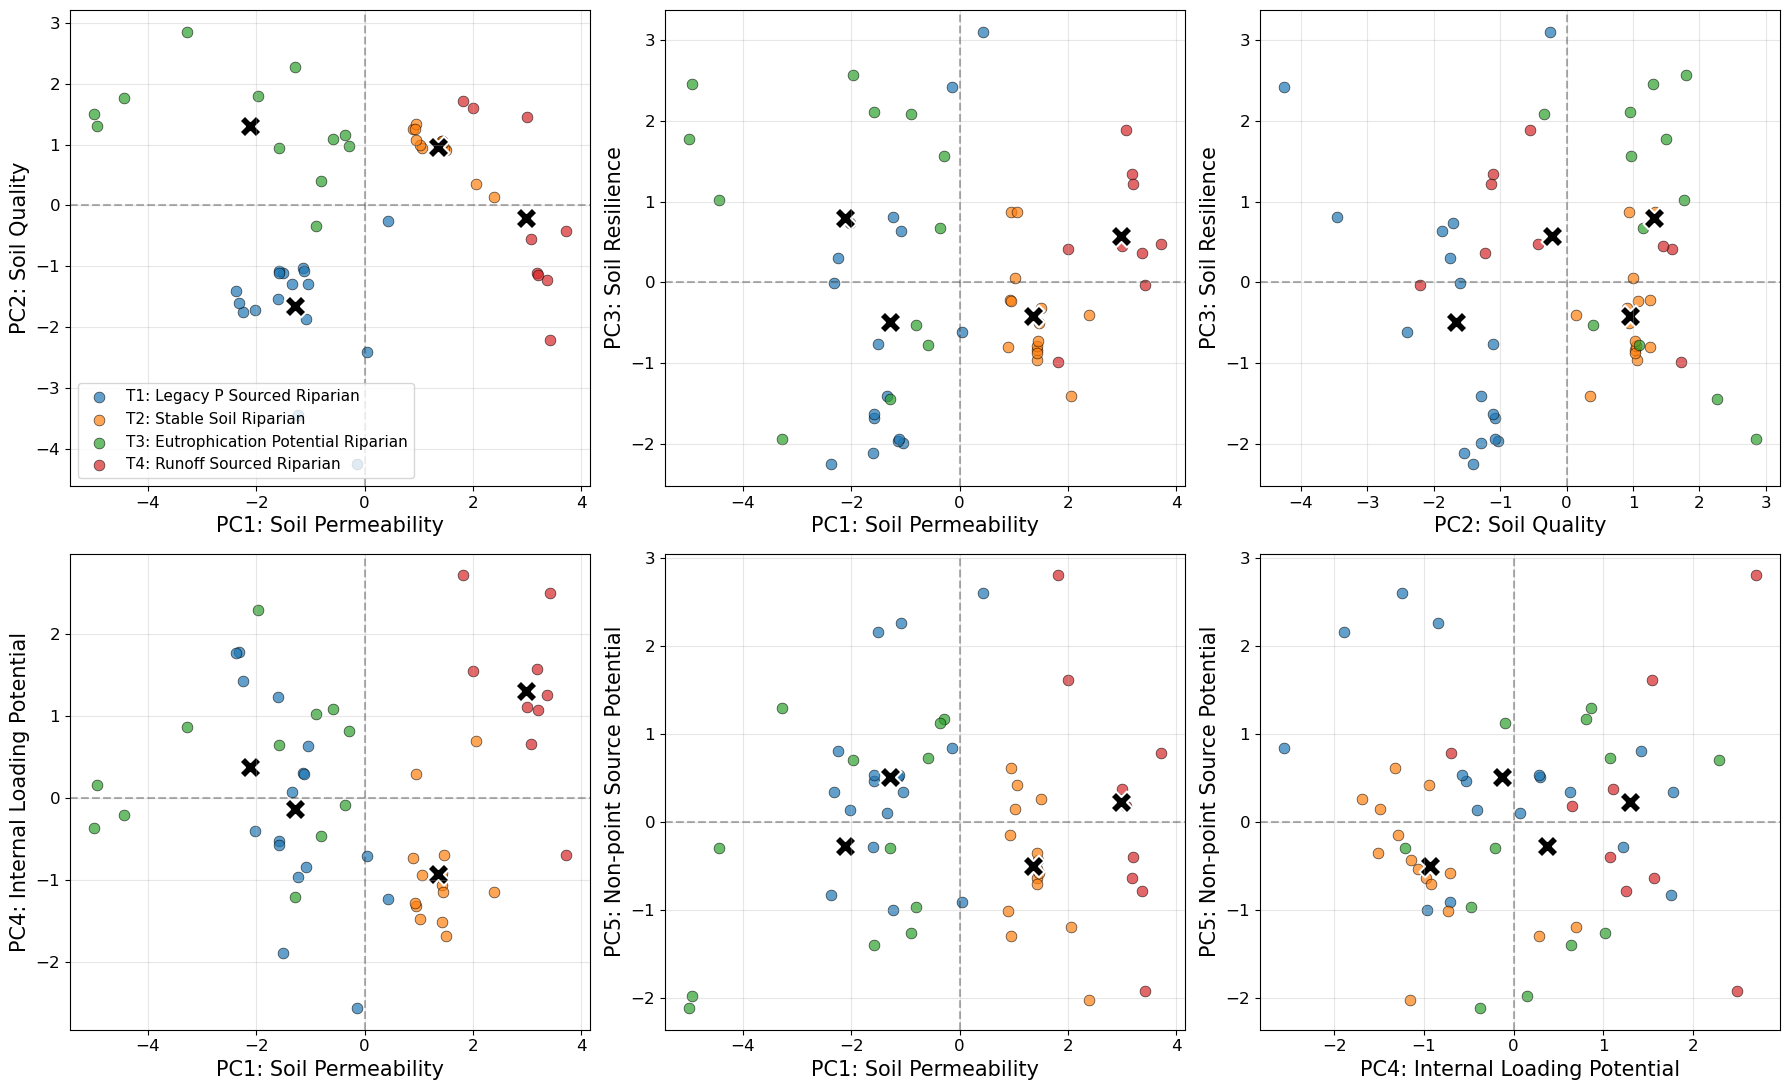

In [12]:
# --- Cluster visualization in PC space (six PC pairs spanning PC1-PC5) ---
pairs = [(0, 1), (0, 2), (1, 2), (0, 3), (0, 4), (3, 4)]
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()
for ax, (a, b) in zip(axes, pairs):
    for c in range(K):
        m = labels == c
        ax.scatter(Z[m, a], Z[m, b], c=[PALETTE[c]], s=60, alpha=.7,
                   edgecolors="black", linewidth=.5, label=f"T{c + 1}: {CLUSTER_NAMES[c]}")
    ax.scatter(centers[:, a], centers[:, b], c="black", marker="X", s=250,
               edgecolors="white", linewidth=1.5)
    ax.axhline(0, color="k", ls="--", alpha=.3)
    ax.axvline(0, color="k", ls="--", alpha=.3)
    ax.set(xlabel=f"PC{a+1}: {PC_NAMES[f'PC{a+1}']}",
           ylabel=f"PC{b+1}: {PC_NAMES[f'PC{b+1}']}")
    ax.grid(alpha=.3)
axes[0].legend()
fig.tight_layout()
fig.savefig(FIG / "score-plots.png", dpi=200)
plt.show()

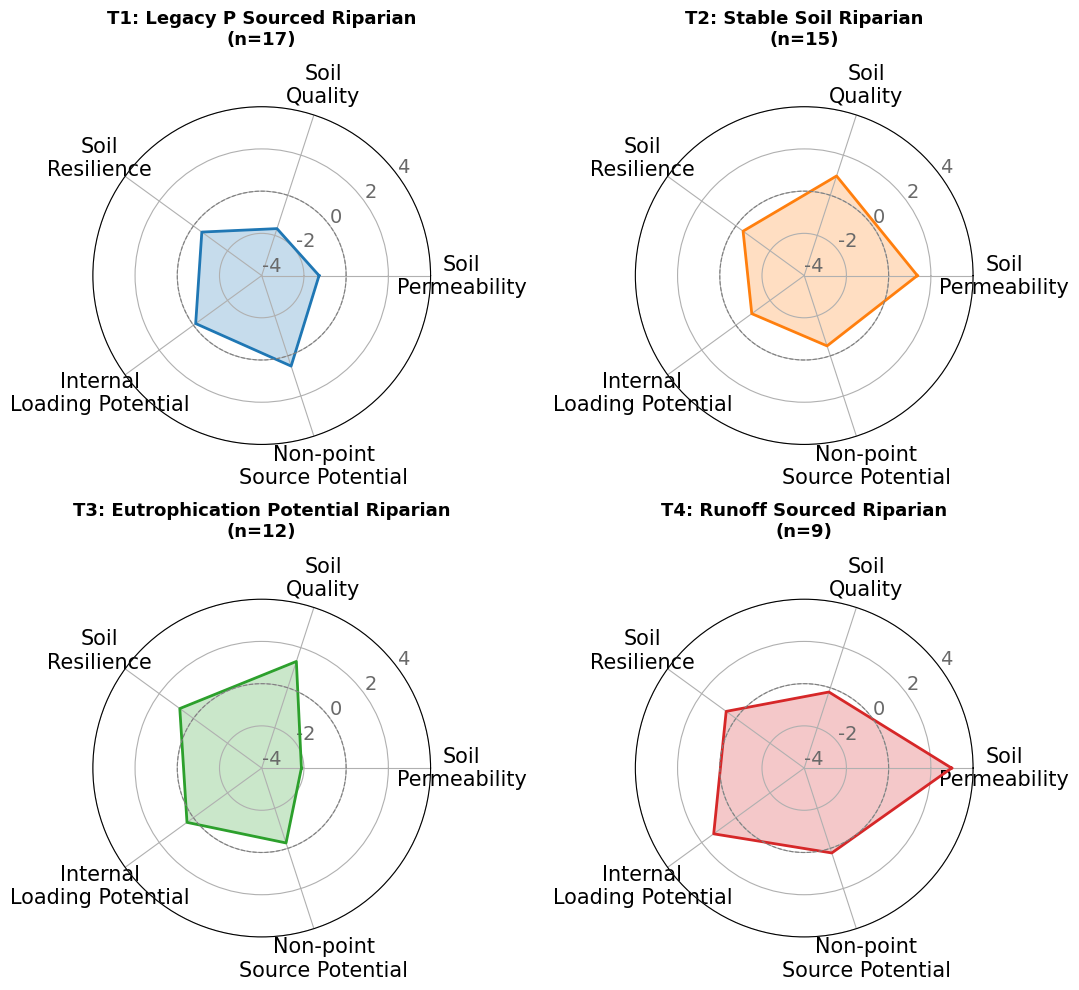

Mean PC scores per cluster:
          PC1   PC2   PC3   PC4   PC5
Cluster                              
0       -1.28 -1.66 -0.49 -0.13  0.51
1        1.36  0.96 -0.42 -0.93 -0.50
2       -2.12  1.31  0.80  0.38 -0.27
3        2.98 -0.21  0.57  1.30  0.23


In [13]:
# --- Radar plots: cluster profiles from mean PC scores (one per cluster) ---
pc_cols = [f"PC{i+1}" for i in range(N_PCS_CLUSTER)]
pc_mean = pd.DataFrame(Z, columns=pc_cols).assign(Cluster=labels).groupby("Cluster").mean()

angles = np.linspace(0, 2 * np.pi, N_PCS_CLUSTER, endpoint=False)
loop = np.concatenate([angles, angles[:1]])
ring = np.linspace(0, 2 * np.pi, 100)
RMIN, RMAX = -4, 4                       # shared radial scale for every cluster
rticks = np.arange(RMIN, RMAX + 1, 2)    # -4, -2, 0, 2, 4

def wrap2(name):
    """Break a component name onto two lines so labels clear the axes."""
    words = name.split()
    if len(words) == 1:
        return name
    mid = len(words) // 2
    return " ".join(words[:mid]) + "\n" + " ".join(words[mid:])

axis_labels = [wrap2(PC_NAMES[f"PC{i+1}"]) for i in range(N_PCS_CLUSTER)]

ncol = 3 if K > 4 else 2
nrow = int(np.ceil(K / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5.5 * ncol, 5 * nrow),
                         subplot_kw=dict(polar=True))
axes = np.atleast_1d(axes).ravel()
for c in range(K):
    ax = axes[c]
    vals = pc_mean.loc[c].tolist() + pc_mean.loc[c].tolist()[:1]
    ax.plot(loop, vals, color=PALETTE[c], lw=2)
    ax.fill(loop, vals, color=PALETTE[c], alpha=.25)
    ax.plot(ring, [0] * 100, color="grey", lw=.8, ls="--")
    ax.set_xticks(angles)
    ax.set_xticklabels(axis_labels, fontsize=15)
    ax.tick_params(axis="x", pad=12)
    ax.set_ylim(RMIN, RMAX)
    ax.set_yticks(rticks)
    ax.set_yticklabels([f"{t:g}" for t in rticks], fontsize=14, color="dimgrey")
    ax.set_rlabel_position(36)
    ax.set_title(f"T{c + 1}: {CLUSTER_NAMES[c]}\n(n={int((labels == c).sum())})",
                 fontsize=13, fontweight="bold", pad=14)
for j in range(K, len(axes)):
    fig.delaxes(axes[j])
fig.tight_layout()
fig.savefig(FIG / "typology-radar.png", dpi=200, bbox_inches="tight")
plt.show()

print("Mean PC scores per cluster:")
print(pc_mean.round(2).to_string())

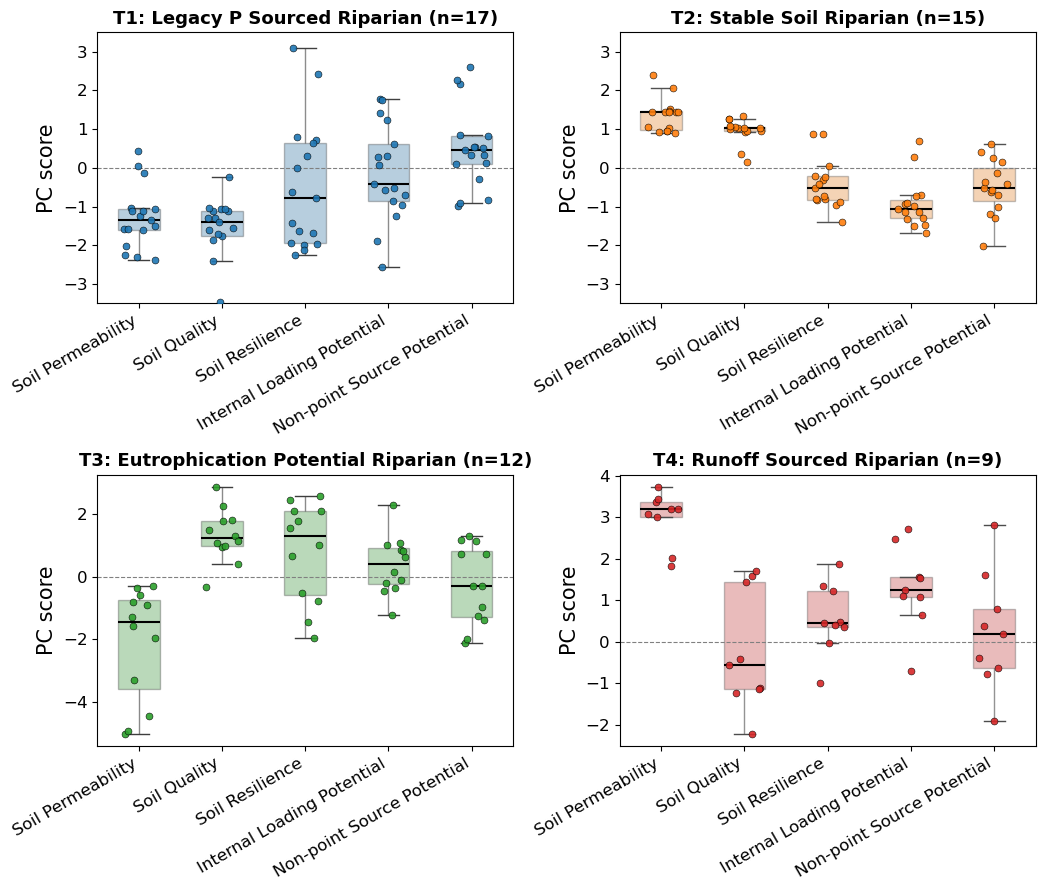

In [14]:
# --- PC-score distribution per cluster: box summary + individual sites ---
pc_long = (pd.DataFrame(Z, columns=pc_cols)
           .assign(Cluster=labels)
           .melt(id_vars="Cluster", var_name="PC", value_name="Score"))
tick_names = [PC_NAMES[p] for p in pc_cols]

np.random.seed(RANDOM_STATE)   # fix strip-plot jitter so the figure is reproducible
ncol = 3 if K > 4 else 2       # top row shares a -3.5..3.5 scale; bottom row auto-scaled
nrow = int(np.ceil(K / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5.3 * ncol, 4.5 * nrow))
axes = np.atleast_1d(axes).ravel()
for c in range(K):
    ax = axes[c]
    sub = pc_long[pc_long["Cluster"] == c]
    n = int((labels == c).sum())
    if n > 1:                          # skip the box for a single-site cluster
        sns.boxplot(data=sub, x="PC", y="Score", order=pc_cols, ax=ax,
                    color=PALETTE[c], width=.5, fliersize=0, showcaps=True,
                    boxprops=dict(alpha=.35), whiskerprops=dict(alpha=.6),
                    medianprops=dict(color="black", lw=1.5))
    sns.stripplot(data=sub, x="PC", y="Score", order=pc_cols, ax=ax,
                  color=PALETTE[c], size=5, jitter=.2,
                  edgecolor="black", linewidth=.4, alpha=.9)
    ax.axhline(0, color="grey", lw=.8, ls="--")
    if c < ncol:                       # top row: common y-limits
        ax.set_ylim(-3.5, 3.5)
    ax.set_title(f"T{c + 1}: {CLUSTER_NAMES[c]} (n={n})", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("PC score")
    ax.set_xticks(range(len(pc_cols)))
    ax.set_xticklabels(tick_names, rotation=30, ha="right", fontsize=12)
for j in range(K, len(axes)):
    fig.delaxes(axes[j])
fig.tight_layout()
fig.savefig(FIG / "pc-score-distribution.png", dpi=200)
plt.show()

In [15]:
# --- Cluster characterization ---
profile = train.groupby("Cluster")[FEATURES].mean().T
profile.index = [VARIABLE_LABELS.get(f, f) for f in profile.index]
print("Mean feature profile per cluster:")
print(profile.round(2).to_string())

print("\nLand cover by cluster:")
print(pd.crosstab(train["Cluster"], train["Land_Cover"]).to_string())

Mean feature profile per cluster:
Cluster                                       0      1      2      3
Geometric Mean TP (µg/L)                  45.96  45.89  41.28  43.82
TP Sen Slope (µg/L)                       -0.36  -0.19  -0.08  -0.14
Soil Tolerance Factor                      2.88   4.00   3.83   3.67
Available Water Storage 0-100 cm          11.51   6.82  18.71   7.25
Available Water Storage 0-25 cm            3.74   2.41   5.82   2.70
Depth to Water Table (cm)                 43.41   0.00  24.25  24.11
Soil Slope                                 9.76   5.93   2.67   9.67
Depth to Restrictive Layer (cm)           65.24   0.00   0.00   0.00
Whole Soil Erodibility Factor              0.27   0.26   0.29   0.12
Soil pH                                    5.11   5.07   5.58   4.83
Percent Clay                               7.14   5.11   6.49   2.00
Saturated Hydraulic Conductivity (in/hr)  10.00  98.51  25.40  98.16
Percent Organic Matter                     7.69   4.01   7.93   4.49


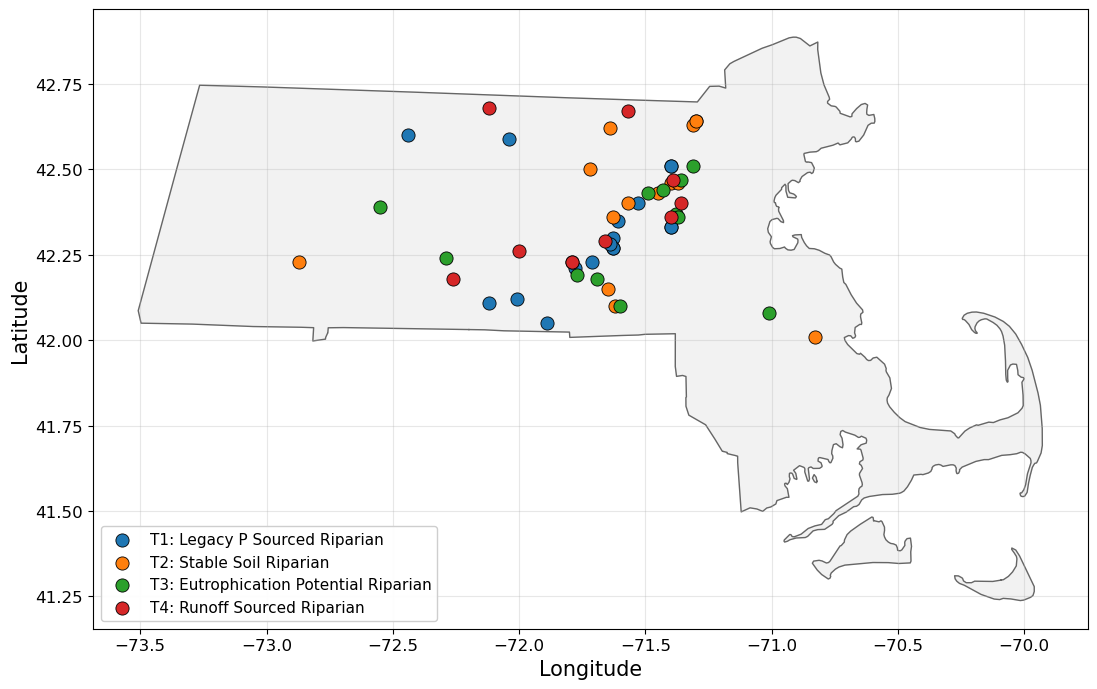

In [16]:
# --- Site map: training stations over the Massachusetts outline ---
import json

ma = json.load(open(ROOT / "data" / "geo" / "massachusetts.geojson"))

def iter_rings(geom):
    if geom["type"] == "Polygon":
        yield from geom["coordinates"]
    else:                                  # MultiPolygon (mainland + islands)
        for poly in geom["coordinates"]:
            yield from poly

fig, ax = plt.subplots(figsize=(12, 7))
for ring in iter_rings(ma["geometry"]):
    xs, ys = zip(*ring)
    ax.fill(xs, ys, color="0.95", zorder=0)
    ax.plot(xs, ys, color="0.4", lw=1, zorder=1)

for c in range(K):
    m = train["Cluster"] == c
    ax.scatter(train.loc[m, "Longitude"], train.loc[m, "Latitude"],
               c=[PALETTE[c]], s=90, edgecolors="black", linewidth=.6,
               label=f"T{c + 1}: {CLUSTER_NAMES[c]}", zorder=3)

ax.set_aspect(1 / np.cos(np.deg2rad(train["Latitude"].mean())))  # geographic aspect
ax.set(xlabel="Longitude", ylabel="Latitude")
ax.legend(loc="lower left", framealpha=.95)
ax.grid(alpha=.3)
fig.tight_layout()
fig.savefig(FIG / "typology-site-map.png", dpi=200, bbox_inches="tight")
plt.show()

## Type interpretation (Ward, K = 4)

With the corrected soil attributes for Elizabeth Br, Stow, the earlier singleton
disappears and the training sites resolve into **four balanced riparian stream
types (T1–T4)**. Signals below reference the mean/median principal-component
scores and the raw soil / water-quality features. The components describe stream
TP dynamics (concentration and Sen slope) alongside surrounding soil properties
and land use: **PC1 Soil Permeability, PC2 Soil Quality, PC3 Soil Resilience,
PC4 Internal Loading Potential, PC5 Non-point Source Potential.**

| Type | n | Name | Distinguishing signals | Dominant land cover |
|---|---|---|---|---|
| **T1 — Legacy P Sourced Riparian** | 17 | High standing TP retained in low-permeability soils, with a declining trend (legacy phosphorus rather than new inputs) | Low KSAT (~10 in/hr), high TP (~46 µg/L), most negative Sen slope (~-0.4), deep water table; -PC1, -PC2 | Developed medium / deciduous forest / woody wetlands |
| **T2 — Stable Soil Riparian** | 15 | Permeable, high-quality soils with the lowest internal-loading potential | Highest KSAT (~98), +PC1 (permeability), +PC2 (soil quality), lowest PC4 (internal loading ~-0.9) | Developed medium / low intensity |
| **T3 — Eutrophication Potential Riparian** | 12 | Wet, organic-rich soils with elevated internal-loading potential | Highest available water storage (~19), highest OM (~8%) and pH; +PC2, +PC3, +PC4 (median +0.40) | Developed medium / woody wetlands |
| **T4 — Runoff Sourced Riparian** | 9 | Highly permeable sandy soils on steep, forested / agricultural land — non-point runoff delivery | Highest KSAT (~98), lowest clay (~2%), steepest slope; strongly +PC1, highest PC4 (median +1.26) | Mixed / evergreen forest, pasture |

**Which PCs define each type (for the discussion):** PC1 (Soil Permeability)
is the primary axis, separating the permeable Stable (T2) and Runoff (T4) types
from the low-permeability Legacy-P (T1) and Eutrophication (T3) types. PC4
(Internal Loading Potential) is highest in **T4 (Runoff Sourced, median +1.26)**
and **T3 (Eutrophication Potential, +0.40)** — these two types carry the most
internal-loading signal and are the natural candidates for further monitoring and
remediation. The Legacy-P type (T1) is instead defined by high *standing* TP with
a declining Sen slope, i.e. a stock of legacy phosphorus rather than an active
loading trend.

> Type IDs (T1–T4) are the 1-indexed display labels; the saved `Cluster` column
> remains 0-indexed (T1 = Cluster 0, …, T4 = Cluster 3), with a `Type_ID` column
> holding the T-label.

In [17]:
# --- Save the labeled typology and the fitted model bundle ---
# Classification for new sites uses nearest centroid, so the bundle works for
# either method (Ward has no native predict()).
# Type_ID is the 1-indexed display label (T1..TK); Cluster stays 0-indexed.
train[ID_COLS + FEATURES + ["Cluster"]].assign(
    Type_ID=train["Cluster"].map(lambda c: f"T{c + 1}"),
    Type=train["Cluster"].map(CLUSTER_NAMES)).to_csv(
    OUT / "typology-training-labeled.csv", index=False)

joblib.dump({
    "scaler": scaler, "pca": pca,
    "cluster_method": CLUSTER_METHOD, "k": K, "centroids": centers,
    "features": FEATURES, "id_cols": ID_COLS, "lulc_mapping": lulc_mapping,
    "pc_names": PC_NAMES, "cluster_names": CLUSTER_NAMES,
    "variable_labels": VARIABLE_LABELS,
    "n_pcs_cluster": N_PCS_CLUSTER, "test_sites": TEST_SITES,
    "train_scores": Z, "train_labels": labels,
}, OUT / "typology-model.joblib")
print(f"Saved typology ({CLUSTER_METHOD}, K={K}) and model bundle to", OUT)

Saved typology (ward, K=4) and model bundle to /home/jbo/Projects/stream-station-typology/results
